In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string 
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import sent_tokenize,word_tokenize




In [6]:
df=pd.read_csv('makeup_products.csv',header=0,index_col=0)
df.reset_index(drop=True, inplace=True)
df.head()

,brand,name,price,price_sign,currency,image_link,product_link,website_link,description,rating,category,product_type,tag_list,created_at,updated_at,product_api_url,api_featured_image,product_colors
0,colourpop,Lippie Pencil,5.0,$,CAD,https://cdn.shopify.com/s/files/1/1338/0845/co...,https://colourpop.com/collections/lippie-pencil,https://colourpop.com,Lippie Pencil A long-wearing and high-intensit...,NaN,pencil,lip_liner,"['cruelty free', 'Vegan']",2018-07-08T23:45:08.056Z,2018-07-09T00:53:23.301Z,http://makeup-api.herokuapp.com/api/v1/product...,//s3.amazonaws.com/donovanbailey/products/api_...,"[{'hex_value': '#B28378', 'colour_name': 'BFF ..."
1,colourpop,Blotted Lip,5.5,$,CAD,https://cdn.shopify.com/s/files/1/1338/0845/pr...,https://colourpop.com/collections/lippie-stix?...,https://colourpop.com,Blotted Lip Sheer matte lipstick that creates ...,NaN,lipstick,lipstick,"['cruelty free', 'Vegan']",2018-07-08T22:01:20.178Z,2018-07-09T00:53:23.287Z,http://makeup-api.herokuapp.com/api/v1/product...,//s3.amazonaws.com/donovanbailey/products/api_...,"[{'hex_value': '#b72227', 'colour_name': ""Bee'..."
2,colourpop,Lippie Stix,5.5,$,CAD,https://cdn.shopify.com/s/files/1/1338/0845/co...,https://colourpop.com/collections/lippie-stix,https://colourpop.com,"Lippie Stix Formula contains Vitamin E, Mango,...",NaN,lipstick,lipstick,"['cruelty free', 'Vegan']",2018-07-08T21:47:49.858Z,2018-07-09T00:53:23.274Z,http://makeup-api.herokuapp.com/api/v1/product...,//s3.amazonaws.com/donovanbailey/products/api_...,"[{'hex_value': '#F2DEC3', 'colour_name': 'Fair..."
3,colourpop,No Filter Foundation,12.0,$,CAD,https://cdn.shopify.com/s/files/1/1338/0845/pr...,https://colourpop.com/products/no-filter-matte...,https://colourpop.com/products/no-filter-matte...,"Developed for the Selfie Age, our buildable fu...",NaN,liquid,foundation,"['cruelty free', 'Vegan']",2018-07-08T18:22:25.273Z,2018-07-09T00:53:23.313Z,http://makeup-api.herokuapp.com/api/v1/product...,//s3.amazonaws.com/donovanbailey/products/api_...,"[{'hex_value': '#F2DEC3', 'colour_name': 'Fair..."
4,boosh,Lipstick,26.0,$,CAD,https://cdn.shopify.com/s/files/1/1016/3243/pr...,https://www.boosh.ca/collections/all,https://www.boosh.ca/,All of our products are free from lead and hea...,NaN,lipstick,lipstick,"['Chemical Free', 'Organic']",2018-07-08T17:32:28.088Z,2018-09-02T22:52:06.669Z,http://makeup-api.herokuapp.com/api/v1/product...,//s3.amazonaws.com/donovanbailey/products/api_...,"[{'hex_value': '#CB4975', 'colour_name': 'Babs..."


In [9]:
df1=df[['product_type','description']]
df1.head()

,product_type,description
0,lip_liner,Lippie Pencil A long-wearing and high-intensit...
1,lipstick,Blotted Lip Sheer matte lipstick that creates ...
2,lipstick,"Lippie Stix Formula contains Vitamin E, Mango,..."
3,foundation,"Developed for the Selfie Age, our buildable fu..."
4,lipstick,All of our products are free from lead and hea...


In [10]:
df1.columns=['Product','Description']
df1.head()

,Product,Description
0,lip_liner,Lippie Pencil A long-wearing and high-intensit...
1,lipstick,Blotted Lip Sheer matte lipstick that creates ...
2,lipstick,"Lippie Stix Formula contains Vitamin E, Mango,..."
3,foundation,"Developed for the Selfie Age, our buildable fu..."
4,lipstick,All of our products are free from lead and hea...


In [11]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 931 entries, 0 to 930
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Product      931 non-null    object
 1   Description  906 non-null    object
dtypes: object(2)
memory usage: 14.7+ KB


In [12]:
df1.shape

(931, 2)

In [13]:
df.shape

(931, 18)

In [14]:
df1[df1.duplicated()].shape


(58, 2)

In [15]:
df2=df1.drop_duplicates(keep='first')
df2.shape

(873, 2)

In [16]:
df2.isnull().sum()


Product        0
Description    7
dtype: int64

In [17]:
df3=df2.dropna(how='any')
df3.shape 

(866, 2)

In [10]:
df3.isnull().sum()

Product        0
Description    0
dtype: int64

In [18]:
df3.head()

,Product,Description
0,lip_liner,Lippie Pencil A long-wearing and high-intensit...
1,lipstick,Blotted Lip Sheer matte lipstick that creates ...
2,lipstick,"Lippie Stix Formula contains Vitamin E, Mango,..."
3,foundation,"Developed for the Selfie Age, our buildable fu..."
4,lipstick,All of our products are free from lead and hea...


In [11]:
df3['Product'].unique()

array(['lip_liner', 'lipstick', 'foundation', 'eyeliner', 'eyeshadow',
       'blush', 'bronzer', 'mascara', 'eyebrow', 'nail_polish'],
      dtype=object)

In [25]:
df3['Product'].nunique()

10

In [19]:
prod_df=df3['Product'].value_counts().reset_index()
prod_df


,Product,count
0,foundation,156
1,lipstick,144
2,eyeliner,142
3,mascara,88
4,eyeshadow,81
5,blush,71
6,bronzer,67
7,eyebrow,45
8,nail_polish,44
9,lip_liner,28


<Axes: xlabel='count', ylabel='Product'>

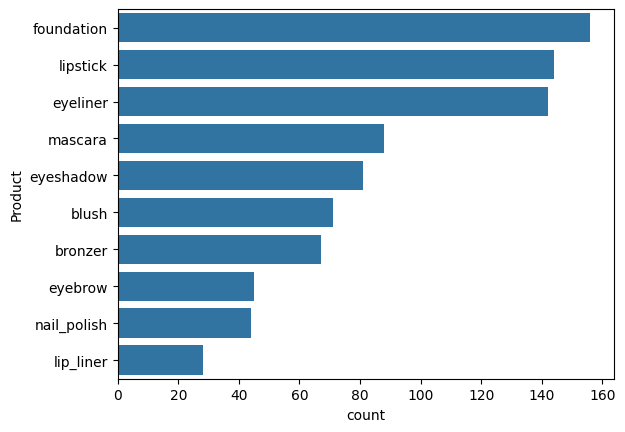

In [20]:
sns.barplot(data=prod_df,x='count',y='Product')


In [21]:
lipstick_text=df3['Description'][3]
lipstick_text

'Developed for the Selfie Age, our buildable full coverage, natural matte foundation delivers flawless looking skin from day-to-night. The oil-free, lightweight formula blends smoothly and is easily customizable to create the coverage you want. Build it up or sheer it out, it was developed with innovative soft-blurring pigments to deliver true color while looking and feeling natural. The lockable pump is easy to use and keeps your routine mess-free! As always, 100% cruelty-free and vegan.'

In [22]:
df3.dtypes

Product        object
Description    object
dtype: object

In [24]:
df3['Description']=df3['Description'].astype(str)

C:\Users\linab\AppData\Local\Temp\ipykernel_23992\3267892822.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['Description']=df3['Description'].astype(str)


In [25]:
df3.dtypes

Product        object
Description    object
dtype: object

In [26]:
def Get_WordCount(text):
    return len(text.split())



In [27]:
lipstick_text

'Developed for the Selfie Age, our buildable full coverage, natural matte foundation delivers flawless looking skin from day-to-night. The oil-free, lightweight formula blends smoothly and is easily customizable to create the coverage you want. Build it up or sheer it out, it was developed with innovative soft-blurring pigments to deliver true color while looking and feeling natural. The lockable pump is easy to use and keeps your routine mess-free! As always, 100% cruelty-free and vegan.'

In [28]:
Get_WordCount(lipstick_text)


75

In [29]:
lipstick_text.split()


['Developed',
 'for',
 'the',
 'Selfie',
 'Age,',
 'our',
 'buildable',
 'full',
 'coverage,',
 'natural',
 'matte',
 'foundation',
 'delivers',
 'flawless',
 'looking',
 'skin',
 'from',
 'day-to-night.',
 'The',
 'oil-free,',
 'lightweight',
 'formula',
 'blends',
 'smoothly',
 'and',
 'is',
 'easily',
 'customizable',
 'to',
 'create',
 'the',
 'coverage',
 'you',
 'want.',
 'Build',
 'it',
 'up',
 'or',
 'sheer',
 'it',
 'out,',
 'it',
 'was',
 'developed',
 'with',
 'innovative',
 'soft-blurring',
 'pigments',
 'to',
 'deliver',
 'true',
 'color',
 'while',
 'looking',
 'and',
 'feeling',
 'natural.',
 'The',
 'lockable',
 'pump',
 'is',
 'easy',
 'to',
 'use',
 'and',
 'keeps',
 'your',
 'routine',
 'mess-free!',
 'As',
 'always,',
 '100%',
 'cruelty-free',
 'and',
 'vegan.']

In [30]:
df3.head(2)

,Product,Description
0,lip_liner,Lippie Pencil A long-wearing and high-intensit...
1,lipstick,Blotted Lip Sheer matte lipstick that creates ...


In [33]:
word_count=df3['word_count'].sum()
print('Total Number of Words=',word_count)

Total Number of Words= 82459


In [34]:
avg_word_count=df3['word_count'].mean()
print('Average Number of words=',round(avg_word_count,2))

Average Number of words= 95.22


In [31]:
df3['word_count']=df3['Description'].apply(lambda x:Get_WordCount(x))
df3.head()

C:\Users\linab\AppData\Local\Temp\ipykernel_23992\4274265032.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['word_count']=df3['Description'].apply(lambda x:Get_WordCount(x))


,Product,Description,word_count
0,lip_liner,Lippie Pencil A long-wearing and high-intensit...,37
1,lipstick,Blotted Lip Sheer matte lipstick that creates ...,22
2,lipstick,"Lippie Stix Formula contains Vitamin E, Mango,...",29
3,foundation,"Developed for the Selfie Age, our buildable fu...",75
4,lipstick,All of our products are free from lead and hea...,55


In [32]:
df3.head()


,Product,Description,word_count
0,lip_liner,Lippie Pencil A long-wearing and high-intensit...,37
1,lipstick,Blotted Lip Sheer matte lipstick that creates ...,22
2,lipstick,"Lippie Stix Formula contains Vitamin E, Mango,...",29
3,foundation,"Developed for the Selfie Age, our buildable fu...",75
4,lipstick,All of our products are free from lead and hea...,55


In [35]:
df3.describe()

,word_count
count,866.000000
mean,95.218245
std,121.006854
min,2.000000
25%,34.000000
50%,54.000000
75%,105.000000
max,822.000000


In [39]:
df3[df3['word_count']==822].iloc[0,1]


'Smashbox Cosmetics has collaborated with the effortlessly cool and hilarious "Barely Famous" (VH1) sisters, Erin and Sara Foster, to celebrate the launch of the new Be Legendary Lipstick collection. The sisters personalized selections illustrates their unforgettable personalities and the enviable shades of the always photo ready lipstick. Sara chose a soft nude shade, Honey, while Erin chose Mandarin, a vibrant red orange. Both stay put and pop on camera, delivering rich, vibrant color in just 1 swipe.In a pinch, dot cream shades on cheeks for an instant flush.Available in nudes, neutrals, reds, corals, pinks, berries, browns, violets and bolds Pigment-loaded formula glides on and feels lush and light on the lips Moisturizing, satin-smooth creams soften and protect lips with shea butter + vitamins C and E Silky, vitamin-fortified mattes won\'t dry out or settle unevenly on lips\n              \n                Formulated without Parabens, Sodium Lauryl Sulfate, Phthalates, Fragrance &

<Axes: ylabel='Frequency'>

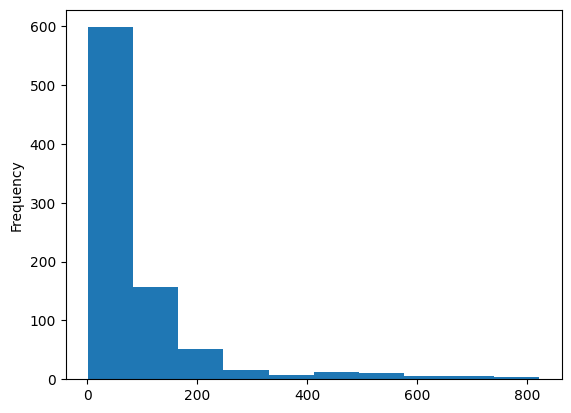

In [40]:
df3.word_count.plot(kind='hist')

<Axes: ylabel='Density'>

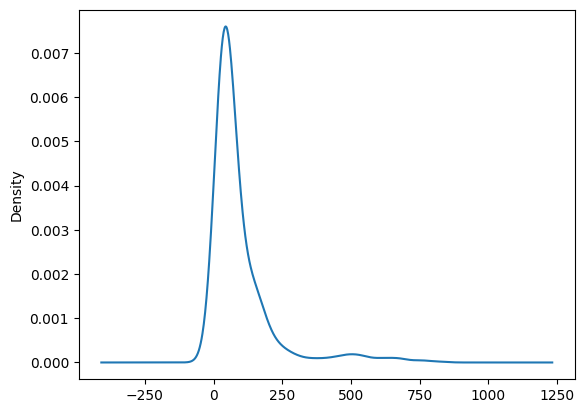

In [41]:
df3.word_count.plot(kind='kde')

<Axes: >

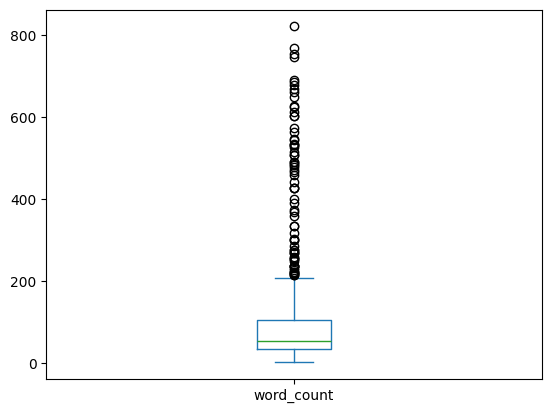

In [42]:
df3['word_count'].plot(kind='box')

In [43]:
df3.sort_values(['word_count'],ascending=False).head(5)

,Product,Description,word_count
466,lipstick,Smashbox Cosmetics has collaborated with the e...,822
426,blush,Pros in our L.A. photo studio bring the sun to...,770
467,lipstick,Makeup artists in our L.A. studio were constan...,754
468,lipstick,"Perfected on-set in our L.A. photo studio, our...",746
460,eyeshadow,Our fab trios are all playfulness and color! G...,692


In [44]:
df3.sort_values(['word_count'],ascending=True).head(5)

,Product,Description,word_count
401,lipstick,lip color,2
414,mascara,waterproof mascara,2
418,mascara,beyond mascara,2
416,mascara,volumizing mascara,2
421,eyeliner,cream eyeshadow,2


In [45]:
lipstick_text


'Developed for the Selfie Age, our buildable full coverage, natural matte foundation delivers flawless looking skin from day-to-night. The oil-free, lightweight formula blends smoothly and is easily customizable to create the coverage you want. Build it up or sheer it out, it was developed with innovative soft-blurring pigments to deliver true color while looking and feeling natural. The lockable pump is easy to use and keeps your routine mess-free! As always, 100% cruelty-free and vegan.'

In [46]:
def Get_char_count(text):
    return len(text)
Get_char_count(lipstick_text)

492

In [47]:
df3['char_length']=df3['Description'].apply(lambda x:Get_char_count(x))

C:\Users\linab\AppData\Local\Temp\ipykernel_23992\1956111624.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['char_length']=df3['Description'].apply(lambda x:Get_char_count(x))


In [49]:
df3.head()

,Product,Description,word_count,char_length
0,lip_liner,Lippie Pencil A long-wearing and high-intensit...,37,232
1,lipstick,Blotted Lip Sheer matte lipstick that creates ...,22,146
2,lipstick,"Lippie Stix Formula contains Vitamin E, Mango,...",29,188
3,foundation,"Developed for the Selfie Age, our buildable fu...",75,492
4,lipstick,All of our products are free from lead and hea...,55,357


In [50]:
df3['char_length'].describe()

count     866.000000
mean      658.128176
std       834.875442
min         9.000000
25%       224.000000
50%       358.500000
75%       788.000000
max      5516.000000
Name: char_length, dtype: float64

<Axes: ylabel='Frequency'>

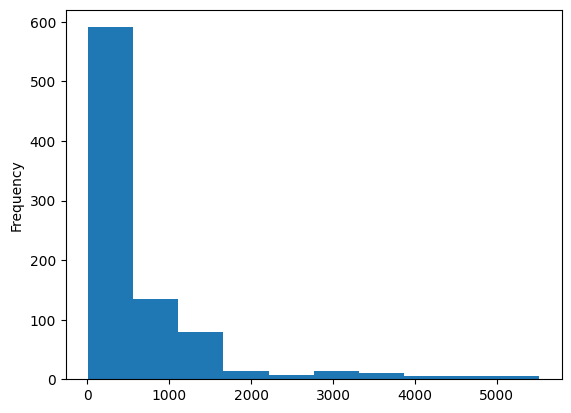

In [51]:
df3['char_length'].plot(kind='hist')

In [52]:
df3.groupby(['Product'])['word_count'].mean()

Product
blush           98.873239
bronzer        105.925373
eyebrow         95.755556
eyeliner        89.359155
eyeshadow      112.950617
foundation      96.538462
lip_liner       73.428571
lipstick        87.701389
mascara         97.670455
nail_polish     87.613636
Name: word_count, dtype: float64

In [53]:
df3.groupby(['Product'])['word_count'].mean().reset_index()

,Product,word_count
0,blush,98.873239
1,bronzer,105.925373
2,eyebrow,95.755556
3,eyeliner,89.359155
4,eyeshadow,112.950617
5,foundation,96.538462
6,lip_liner,73.428571
7,lipstick,87.701389
8,mascara,97.670455
9,nail_polish,87.613636


In [54]:
df3.groupby(['Product'])['word_count'].mean().reset_index().sort_values(['word_count'],ascending=False)

,Product,word_count
4,eyeshadow,112.950617
1,bronzer,105.925373
0,blush,98.873239
8,mascara,97.670455
5,foundation,96.538462
2,eyebrow,95.755556
3,eyeliner,89.359155
7,lipstick,87.701389
9,nail_polish,87.613636
6,lip_liner,73.428571


In [55]:
df3.groupby(['Product'])['char_length'].mean().reset_index().sort_values(['char_length'],ascending=False)

,Product,char_length
4,eyeshadow,779.580247
1,bronzer,724.641791
0,blush,691.267606
5,foundation,688.807692
8,mascara,687.704545
3,eyeliner,625.746479
2,eyebrow,615.711111
9,nail_polish,605.704545
7,lipstick,586.472222
6,lip_liner,483.000000


In [56]:
df3.groupby(['Product'])[['word_count','char_length']].mean().reset_index()

,Product,word_count,char_length
0,blush,98.873239,691.267606
1,bronzer,105.925373,724.641791
2,eyebrow,95.755556,615.711111
3,eyeliner,89.359155,625.746479
4,eyeshadow,112.950617,779.580247
5,foundation,96.538462,688.807692
6,lip_liner,73.428571,483.000000
7,lipstick,87.701389,586.472222
8,mascara,97.670455,687.704545
9,nail_polish,87.613636,605.704545


In [57]:
df3.Product.value_counts().reset_index()

,Product,count
0,foundation,156
1,lipstick,144
2,eyeliner,142
3,mascara,88
4,eyeshadow,81
5,blush,71
6,bronzer,67
7,eyebrow,45
8,nail_polish,44
9,lip_liner,28


In [58]:
def Get_Product_Group(x):
    if x in ['lipstick','lip_liner']:
        return 'lipstick'
    elif x in ['blush','bronzer','contour']:
        return 'Face'
    elif x in ['eyeliner','eyeshadow','mascara','eyebrow']:
        return 'Eye_makeup'
    else:
        return x.capitalize()
    

In [59]:
df3['Product']=df3['Product'].apply(lambda x:Get_Product_Group(x))

C:\Users\linab\AppData\Local\Temp\ipykernel_23992\3050506696.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['Product']=df3['Product'].apply(lambda x:Get_Product_Group(x))


In [60]:
df3.Product.value_counts()

Product
Eye_makeup     356
lipstick       172
Foundation     156
Face           138
Nail_polish     44
Name: count, dtype: int64

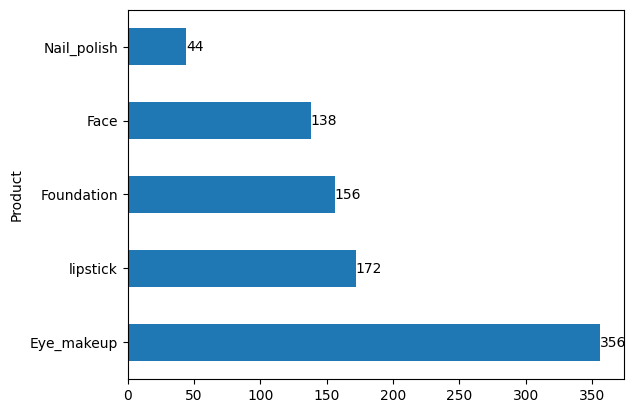

In [61]:
ax=df3.Product.value_counts().plot(kind='barh')
for i in ax.containers:
    ax.bar_label(i)

In [63]:
count_df=df3.groupby(['Product'])[['word_count','char_length']].mean().reset_index()
count_df

,Product,word_count,char_length
0,Eye_makeup,97.589888,674.794944
1,Face,102.297101,707.471014
2,Foundation,96.538462,688.807692
3,Nail_polish,87.613636,605.704545
4,lipstick,85.377907,569.627907


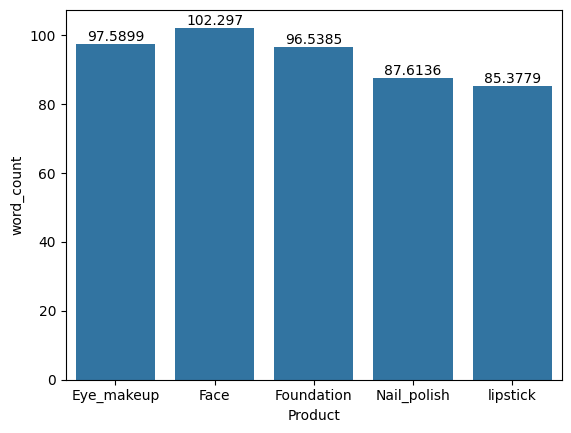

In [64]:
ax=sns.barplot(x=count_df['Product'],y=count_df['word_count'])
for i in ax.containers:
    ax.bar_label(i)

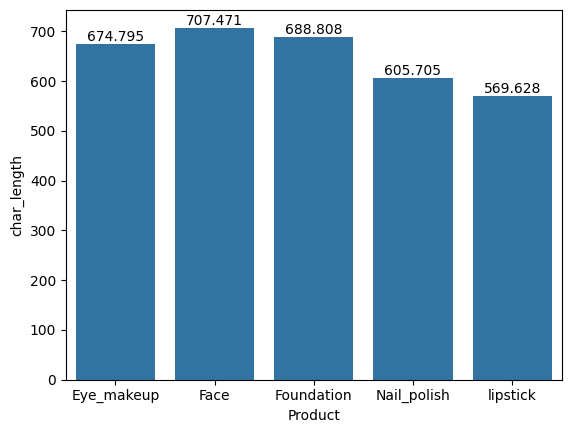

In [66]:
ax=sns.barplot(x=count_df['Product'],y=count_df['char_length'])
for i in ax.containers:
    ax.bar_label(i)


In [67]:
df3.head()

,Product,Description,word_count,char_length
0,lipstick,Lippie Pencil A long-wearing and high-intensit...,37,232
1,lipstick,Blotted Lip Sheer matte lipstick that creates ...,22,146
2,lipstick,"Lippie Stix Formula contains Vitamin E, Mango,...",29,188
3,Foundation,"Developed for the Selfie Age, our buildable fu...",75,492
4,lipstick,All of our products are free from lead and hea...,55,357


In [70]:
from stop_words import get_stop_words
stopword_list=get_stop_words('english')
len(stopword_list)
stopword_list

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 "can't",
 'cannot',
 'could',
 "couldn't",
 'did',
 "didn't",
 'do',
 'does',
 "doesn't",
 'doing',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 "hadn't",
 'has',
 "hasn't",
 'have',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 "here's",
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 "how's",
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 "let's",
 'me',
 'more',
 'most',
 "mustn't",
 'my',
 'myself',
 'no',
 'nor',
 'not',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'ought',
 'our',
 'ours',
 'ourselves',
 'out',
 'over',
 'own',
 'same',
 "shan't",
 'she',
 "she'd",
 "she'll",
 "she's",
 'should',
 "s

In [48]:
lipstick_text

'Physicians Formula Organic Wear Lash Boosting Mascara is the 1st Ever 100% Natural Lash Boosting formula enhances the appearance of \nlash length, thickness and volume for dramatic lashes instantly and \nlong-term.Additional Features:100% of the Total Ingredients are from Natural Origin.  44% of the Total Ingredients are from Organic Farming.  100% saw enhanced lashes INSTANLY!Delivers ingredients to the base of lashes for  best results!93% saw thicker & longer looking lashes instantly!  92% saw \nextended & fuller looking lashes after 4 weeks!  *Based on \nindividual perception of results of a panel of women wearing Organic \nWear Lash Boosting Mascara.Directions for Use: Sweep mascara brush from lash base to tips. Apply multiple coats for \nadded volume. Can easily be washed off with soap and water or removed \nwith Physicians Formula Eye Makeup Remover Pads or Lotions.Ingredients: Citrus Aurantium Dulcis (Orange) Fruit Water *, Glycerin, Iron Oxides, \nMicrocrystalline Cellulose, G

In [71]:
def Remove_stopword(text):
    word_list=[w for w in text.split() if w not in stopword_list]
    return " ".join(word_list)

In [72]:
cleaned_text1=Remove_stopword(lipstick_text)
cleaned_text1

'Developed Selfie Age, buildable full coverage, natural matte foundation delivers flawless looking skin day-to-night. The oil-free, lightweight formula blends smoothly easily customizable create coverage want. Build sheer out, developed innovative soft-blurring pigments deliver true color looking feeling natural. The lockable pump easy use keeps routine mess-free! As always, 100% cruelty-free vegan.'

In [73]:
def text_lowercase(text):
    return text.lower()
cleaned_text2=text_lowercase(cleaned_text1)
cleaned_text2

'developed selfie age, buildable full coverage, natural matte foundation delivers flawless looking skin day-to-night. the oil-free, lightweight formula blends smoothly easily customizable create coverage want. build sheer out, developed innovative soft-blurring pigments deliver true color looking feeling natural. the lockable pump easy use keeps routine mess-free! as always, 100% cruelty-free vegan.'

In [74]:
def remove_numbers(text):
    result=re.sub(r'\d+','',text)
    return result 
cleaned_text3=remove_numbers(cleaned_text2)
cleaned_text3

'developed selfie age, buildable full coverage, natural matte foundation delivers flawless looking skin day-to-night. the oil-free, lightweight formula blends smoothly easily customizable create coverage want. build sheer out, developed innovative soft-blurring pigments deliver true color looking feeling natural. the lockable pump easy use keeps routine mess-free! as always, % cruelty-free vegan.'

In [75]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [76]:
def remove_punctuation(text):
    translator=str.maketrans('','',string.punctuation)
    return text.translate(translator)
cleaned_text4=remove_punctuation(cleaned_text3)
cleaned_text4

'developed selfie age buildable full coverage natural matte foundation delivers flawless looking skin daytonight the oilfree lightweight formula blends smoothly easily customizable create coverage want build sheer out developed innovative softblurring pigments deliver true color looking feeling natural the lockable pump easy use keeps routine messfree as always  crueltyfree vegan'

In [77]:
def remove_whitespace(text):
   return "".join(text.split())
cleaned_text5=remove_whitespace(cleaned_text4)
cleaned_text5

'developedselfieagebuildablefullcoveragenaturalmattefoundationdeliversflawlesslookingskindaytonighttheoilfreelightweightformulablendssmoothlyeasilycustomizablecreatecoveragewantbuildsheeroutdevelopedinnovativesoftblurringpigmentsdelivertruecolorlookingfeelingnaturalthelockablepumpeasyusekeepsroutinemessfreeasalwayscrueltyfreevegan'

In [79]:
def Text_cleaning(text):
    text1=text_lowercase(text)
    text2=Remove_stopword(text1)
    text3=remove_numbers(text2)
    text4=remove_punctuation(text3)
    text5=remove_whitespace(text4)
    return text4
Text_cleaning(lipstick_text)

'developed selfie age buildable full coverage natural matte foundation delivers flawless looking skin daytonight oilfree lightweight formula blends smoothly easily customizable create coverage want build sheer out developed innovative softblurring pigments deliver true color looking feeling natural lockable pump easy use keeps routine messfree always  crueltyfree vegan'

In [80]:
df3['Cleaned_Description']=df3['Description'].apply(lambda x:Text_cleaning(x))
df3.head()

C:\Users\linab\AppData\Local\Temp\ipykernel_23992\3477802637.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['Cleaned_Description']=df3['Description'].apply(lambda x:Text_cleaning(x))


,Product,Description,word_count,char_length,Cleaned_Description
0,lipstick,Lippie Pencil A long-wearing and high-intensit...,37,232,lippie pencil longwearing highintensity lip pe...
1,lipstick,Blotted Lip Sheer matte lipstick that creates ...,22,146,blotted lip sheer matte lipstick creates perfe...
2,lipstick,"Lippie Stix Formula contains Vitamin E, Mango,...",29,188,lippie stix formula contains vitamin e mango a...
3,Foundation,"Developed for the Selfie Age, our buildable fu...",75,492,developed selfie age buildable full coverage n...
4,lipstick,All of our products are free from lead and hea...,55,357,products free lead heavy metals parabens phtha...


In [81]:
df3.Product.value_counts()

Product
Eye_makeup     356
lipstick       172
Foundation     156
Face           138
Nail_polish     44
Name: count, dtype: int64

In [83]:
eye_df=df3[df3['Product']=='Eye_makeup']
eye_df.head()

,Product,Description,word_count,char_length,Cleaned_Description
7,Eye_makeup,<strong>12 hours of long-lasting</strong> inte...,67,546,strong hours longlastingstrong intense color t...
8,Eye_makeup,<strong>Product Description</strong>Anti-aging...,92,751,strongproduct descriptionstrongantiaging formu...
10,Eye_makeup,Let your eyes naturally pop with our B Smudged...,67,392,let eyes naturally pop b smudged subtle eye co...
12,Eye_makeup,Our Multi Purpose Pressed Powders may be used ...,176,1072,multi purpose pressed powders may used blush e...
14,Eye_makeup,Our Multi Purpose Pressed Powders may be used ...,83,537,multi purpose pressed powders may used eye sha...


In [84]:
eye_df1=eye_df[['Cleaned_Description']]
eye_df1.head()

,Cleaned_Description
7,strong hours longlastingstrong intense color t...
8,strongproduct descriptionstrongantiaging formu...
10,let eyes naturally pop b smudged subtle eye co...
12,multi purpose pressed powders may used blush e...
14,multi purpose pressed powders may used eye sha...


In [85]:
def Get_WordList(x):
    l=x.split(" ")
    return l
eye_df1['WordList']=eye_df1['Cleaned_Description'].apply(lambda x:Get_WordList(x))

C:\Users\linab\AppData\Local\Temp\ipykernel_23992\4250575792.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eye_df1['WordList']=eye_df1['Cleaned_Description'].apply(lambda x:Get_WordList(x))


In [86]:
eye_df1.head()

,Cleaned_Description,WordList
7,strong hours longlastingstrong intense color t...,"[strong, hours, longlastingstrong, intense, co..."
8,strongproduct descriptionstrongantiaging formu...,"[strongproduct, descriptionstrongantiaging, fo..."
10,let eyes naturally pop b smudged subtle eye co...,"[let, eyes, naturally, pop, b, smudged, subtle..."
12,multi purpose pressed powders may used blush e...,"[multi, purpose, pressed, powders, may, used, ..."
14,multi purpose pressed powders may used eye sha...,"[multi, purpose, pressed, powders, may, used, ..."


In [87]:
List_of_lists=eye_df1['WordList'].to_list()

In [91]:
List_of_lists

[['strong',
  'hours',
  'longlastingstrong',
  'intense',
  'color',
  'transferfree',
  'leaves',
  'trace',
  'crease',
  'eyelid',
  'strongpure',
  'light',
  'capture®strong',
  'strongmineralsstrong',
  'deliver',
  'color',
  'radiance',
  'silky',
  'lines',
  'refreshingly',
  'light',
  'pure',
  'argan',
  'eyeliner',
  'leaves',
  'weightless',
  'feel',
  'eyelidsp',
  'alignleftnatural',
  'cosmetic',
  'certified',
  'ecocert',
  'greenlife',
  'according',
  'ecocert',
  'standard',
  'available',
  'at',
  'httpcosmetiquesecocertcomp',
  'total',
  'ingredients',
  'natural',
  'origin',
  '',
  'total',
  'ingredients',
  'organic',
  'farming'],
 ['strongproduct',
  'descriptionstrongantiaging',
  'formula',
  'made',
  'organic',
  'pure',
  'argan',
  'oil',
  'pure',
  'light',
  'capturesup®sup',
  'pigments',
  '',
  'hour',
  'creasefree',
  'intensity',
  'no',
  'buildup',
  'increase',
  'eyelid',
  'running',
  'pure',
  'light',
  'capture®',
  'pigments'

In [92]:
from itertools import chain
Complete_Word_list=list(chain(*List_of_lists))
Complete_Word_list[:50]

['strong',
 'hours',
 'longlastingstrong',
 'intense',
 'color',
 'transferfree',
 'leaves',
 'trace',
 'crease',
 'eyelid',
 'strongpure',
 'light',
 'capture®strong',
 'strongmineralsstrong',
 'deliver',
 'color',
 'radiance',
 'silky',
 'lines',
 'refreshingly',
 'light',
 'pure',
 'argan',
 'eyeliner',
 'leaves',
 'weightless',
 'feel',
 'eyelidsp',
 'alignleftnatural',
 'cosmetic',
 'certified',
 'ecocert',
 'greenlife',
 'according',
 'ecocert',
 'standard',
 'available',
 'at',
 'httpcosmetiquesecocertcomp',
 'total',
 'ingredients',
 'natural',
 'origin',
 '',
 'total',
 'ingredients',
 'organic',
 'farming',
 'strongproduct',
 'descriptionstrongantiaging']

In [94]:
len(Complete_Word_list)

26487

In [95]:
filter_words=[w for w in Complete_Word_list if len(w)>2]
len(filter_words)

22939

In [96]:
from collections import Counter
word_count_dict=Counter(filter_words)
word_count_dict

Counter({'eye': 254,
         'lashes': 202,
         'brush': 179,
         'iron': 178,
         'formula': 163,
         'oil': 159,
         'oxides': 158,
         'eyes': 155,
         'mascara': 130,
         'color': 127,
         'liner': 127,
         'ingredients': 123,
         'lash': 123,
         'look': 120,
         'line': 118,
         'natural': 117,
         'time': 112,
         'eyeliner': 100,
         'lake': 99,
         'ferric': 98,
         'brow': 97,
         'ferrocyanide': 97,
         'sodium': 96,
         'oxide': 96,
         'glycol': 95,
         'can': 94,
         'shades': 93,
         'may': 92,
         'chromium': 92,
         'mica': 91,
         'titanium': 90,
         'ingredient': 90,
         'dioxide': 89,
         'use': 89,
         'please': 89,
         'list': 89,
         'shadow': 84,
         'create': 83,
         'tip': 83,
         'pencil': 82,
         'makeup': 79,
         'wax': 79,
         'without': 77,
         'ca

In [97]:
word=list(word_count_dict.keys())
count=list(word_count_dict.values())

In [98]:
WordCount_df=pd.DataFrame({'word':word,'Frequency':count})
WordCount_df.head()

,word,Frequency
0,strong,4
1,hours,25
2,longlastingstrong,1
3,intense,46
4,color,127


In [100]:
WordCount_df1=WordCount_df.sort_values(['Frequency'],ascending=False)
top10_words=WordCount_df1.head(10)
top10_words

,word,Frequency
72,eye,254
76,lashes,202
209,brush,179
1371,iron,178
42,formula,163
44,oil,159
1372,oxides,158
67,eyes,155
222,mascara,130
4,color,127


<Axes: xlabel='Frequency', ylabel='word'>

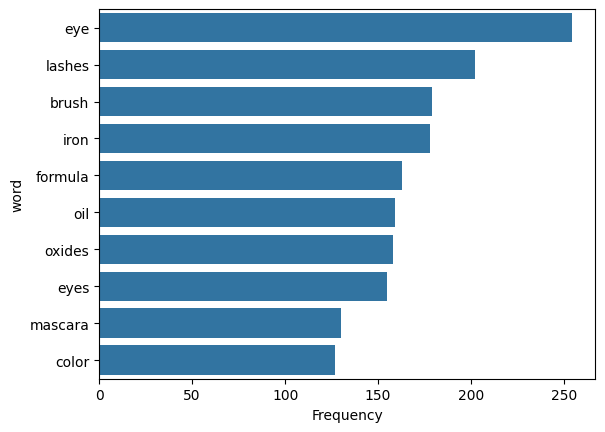

In [101]:
sns.barplot(data=top10_words,y='word',x='Frequency')

In [119]:
def Get_Top10_WOrd(Product):
    prod_df=df3[df3['Product']==Product][['Cleaned_Description']]
    prod_df['WordList']=prod_df['Cleaned_Description'].apply(lambda x:Get_WordList(x))
    List_of_lists=prod_df['WordList'].to_list()
    Complete_Word_list=list(chain(*List_of_lists))
    filter_words=[w for w in Complete_Word_list if len(w)>2]
    word_count_dict=Counter(filter_words)
    word=list(word_count_dict.keys())
    count=list(word_count_dict.values())
    WordCount_df=pd.DataFrame({'Word':word,'Frequency':count})
   # WordCount_df.head()
    WordCount_df1=WordCount_df.sort_values(['Frequency'],ascending=False)
    top10_words=WordCount_df1.head(10)
    ax=sns.barplot(data=top10_words,y='word',x='Frequency')
    for i in ax.containers:
        ax.bar_label(i)
        #return top10_words

In [ ]:
Get_Top10_WOrd('eyeliner')